In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:


np.random.seed(42)
tf.random.set_seed(42)

In [3]:


df = pd.read_csv("pima-indians-diabetes.csv")

df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [4]:
import os
print(os.listdir())

['.config', 'pima-indians-diabetes.csv', 'sample_data']


In [5]:
print("Shape:", df.shape)

df.info()

Shape: (767, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   6       767 non-null    int64  
 1   148     767 non-null    int64  
 2   72      767 non-null    int64  
 3   35      767 non-null    int64  
 4   0       767 non-null    int64  
 5   33.6    767 non-null    float64
 6   0.627   767 non-null    float64
 7   50      767 non-null    int64  
 8   1       767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


In [7]:
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    "pima-indians-diabetes.csv",
    names=columns
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [10]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [13]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 0.96054099,  1.20788789, -0.29601471, ..., -0.58221684,
        -0.55579092,  0.56103382],
       [ 1.86648903, -1.67775979,  1.98813468, ...,  0.44897876,
        -0.58306107,  1.15306018],
       [-0.5493724 ,  0.03460257,  0.3565994 , ...,  0.499902  ,
         0.01688223, -0.6230189 ],
       ...,
       [-0.5493724 , -1.23381399, -0.94862882, ..., -0.44217793,
         3.70138246, -0.70759409],
       [ 0.05459296,  2.00064824,  0.46536842, ...,  0.6399409 ,
        -0.64669142, -0.20014293],
       [-0.85135507, -1.58262854,  0.46536842, ...,  0.15617013,
        -0.16794879, -1.04589487]])

In [14]:
model = Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6741 - loss: 0.6185 - val_accuracy: 0.6911 - val_loss: 0.6017
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6986 - loss: 0.5864 - val_accuracy: 0.6911 - val_loss: 0.5741
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7128 - loss: 0.5621 - val_accuracy: 0.6992 - val_loss: 0.5515
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7251 - loss: 0.5433 - val_accuracy: 0.7154 - val_loss: 0.5339
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7291 - loss: 0.5290 - val_accuracy: 0.7073 - val_loss: 0.5192
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7352 - loss: 0.5172 - val_accuracy: 0.7236 - val_loss: 0.5066
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7413 - loss: 0.5069 - val_accuracy: 0.7398 - val_loss: 0.4965
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7434 - loss: 0.4982 - val_accuracy: 0.7561 - val_loss

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.5210404992103577
Test Accuracy: 0.7402597665786743
Final Test Accuracy: 74.03%


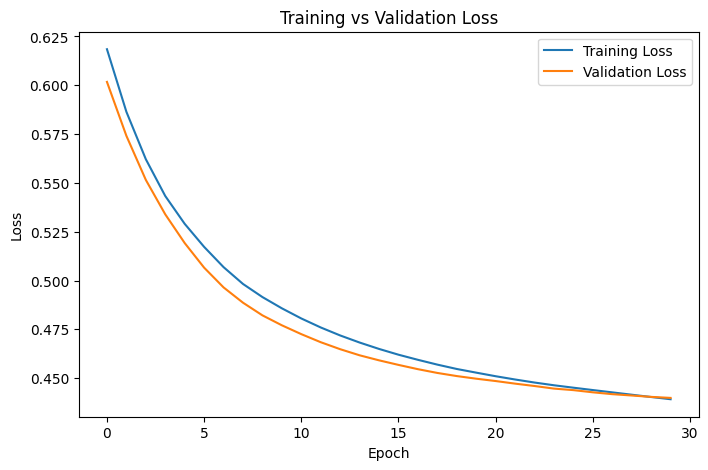

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

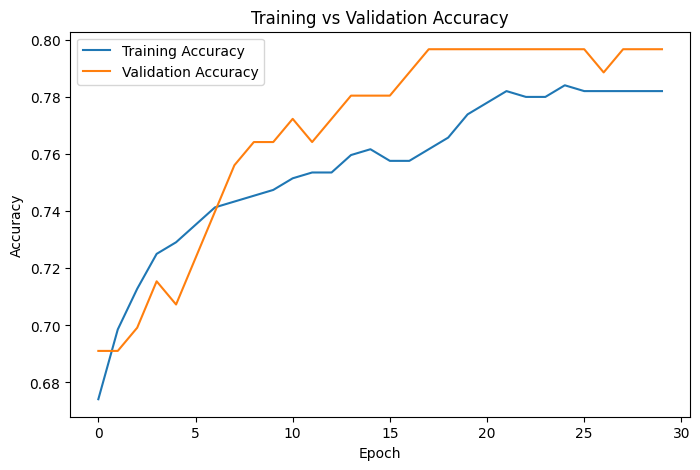

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

In [20]:
probabilities = model.predict(X_test_scaled)

predictions = (probabilities >= 0.5).astype(int)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})

comparison.head(10)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,Actual,Predicted
0,0,1
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,1,0
7,1,1
8,0,0
9,0,1
